# EDA — Transfermarkt Player Market Values
**Source**: `transfermarkt/` — mexwell Kaggle dataset (CC0): `players.csv`, `player_valuations.csv`, `clubs.csv`, `games.csv`, `appearances.csv`, `game_events.csv`, `club_games.csv`, `competitions.csv`

**Purpose**: Profile player market values as a team talent-depth feature. Check coverage for WC 2026 nations, market value distributions, recency of valuations, and feasibility of squad-level aggregation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
DATA = Path('../data/raw/transfermarkt')

## 1. Load & Basic Profile

In [2]:
players = pd.read_csv(DATA / 'players.csv', parse_dates=['date_of_birth', 'contract_expiration_date'])
valuations = pd.read_csv(DATA / 'player_valuations.csv', parse_dates=['date'])
clubs = pd.read_csv(DATA / 'clubs.csv')

print('Players shape:', players.shape)
print('Columns:', players.columns.tolist())
print()
print('Valuations shape:', valuations.shape)
print('Columns:', valuations.columns.tolist())
print('Valuation date range:', valuations['date'].min(), '->', valuations['date'].max())
print()
print('Clubs shape:', clubs.shape)
players.head(3)

Players shape: (47716, 26)
Columns: ['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']

Valuations shape: (507815, 6)
Columns: ['player_id', 'date', 'market_value_in_eur', 'current_club_name', 'current_club_id', 'player_club_domestic_competition_id']
Valuation date range: 2000-01-20 00:00:00 -> 2026-02-27 00:00:00

Clubs shape: (796, 17)


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0


In [3]:
print('Missing values in players.csv:')
missing = players.isnull().mean().mul(100).round(1)
print(missing[missing > 0].sort_values(ascending=False))

Missing values in players.csv:
current_national_team_id                94.9
international_goals                     63.1
international_caps                      63.1
agent_name                              46.2
contract_expiration_date                34.3
market_value_in_eur                     34.0
highest_market_value_in_eur             34.0
country_of_birth                        10.8
foot                                    10.7
city_of_birth                           10.2
height_in_cm                             7.7
first_name                               6.5
current_club_domestic_competition_id     4.8
current_club_name                        4.8
sub_position                             1.0
country_of_citizenship                   0.6
date_of_birth                            0.1
dtype: float64


## 2. Current Market Value Distribution

Players with market value: 31507 / 47716 (66.0%)


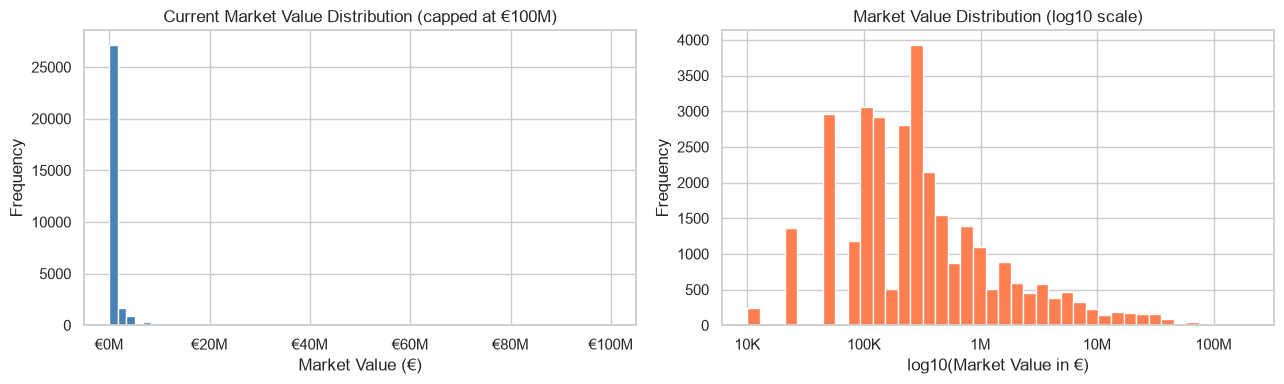

Median market value: €0.25M
Mean market value: €1.61M
Max market value: €200M

Top 10 most valuable players:
           name country_of_citizenship position  value_m
 Erling Haaland                 Norway   Attack    200.0
  Kylian Mbappé                 France   Attack    180.0
Vinicius Junior                 Brazil   Attack    180.0
Jude Bellingham                England Midfield    160.0
     Phil Foden                England Midfield    150.0
    Bukayo Saka                England   Attack    130.0
  Michael Olise                 France   Attack    130.0
  Jamal Musiala                Germany Midfield    130.0
 Alexander Isak                 Sweden   Attack    120.0
    Declan Rice                England Midfield    120.0


In [4]:
players_with_value = players.dropna(subset=['market_value_in_eur'])
print(f'Players with market value: {len(players_with_value)} / {len(players)} ({len(players_with_value)/len(players)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw distribution
players_with_value['market_value_in_eur'].clip(0, 1e8).plot(
    kind='hist', bins=60, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Current Market Value Distribution (capped at €100M)')
axes[0].set_xlabel('Market Value (€)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.0f}M'))

# Log distribution
np.log10(players_with_value['market_value_in_eur'].clip(1)).plot(
    kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Market Value Distribution (log10 scale)')
axes[1].set_xlabel('log10(Market Value in €)')
axes[1].set_xticks([4, 5, 6, 7, 8])
axes[1].set_xticklabels(['10K', '100K', '1M', '10M', '100M'])

plt.tight_layout()
plt.show()

print(f'Median market value: €{players_with_value["market_value_in_eur"].median()/1e6:.2f}M')
print(f'Mean market value: €{players_with_value["market_value_in_eur"].mean()/1e6:.2f}M')
print(f'Max market value: €{players_with_value["market_value_in_eur"].max()/1e6:.0f}M')
print()
print('Top 10 most valuable players:')
print(players_with_value.nlargest(10, 'market_value_in_eur')[
    ['name', 'country_of_citizenship', 'position', 'market_value_in_eur']
].assign(value_m=lambda x: (x['market_value_in_eur']/1e6).round(1)).drop(columns='market_value_in_eur').to_string(index=False))

## 3. Market Value by Position

Market value by position:
            count  median_m  mean_m
position                           
Attack       8676      0.28    1.94
Defender    10097      0.25    1.51
Midfield     9136      0.25    1.77
Goalkeeper   3497      0.15    0.75
Missing       101      0.10    0.12


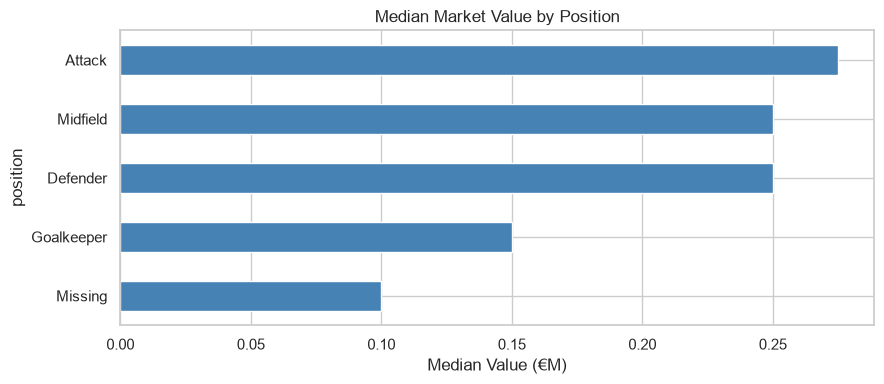

In [5]:
pos_value = players_with_value.groupby('position')['market_value_in_eur'].agg(['median', 'mean', 'count'])
pos_value['median_m'] = pos_value['median'] / 1e6
pos_value['mean_m'] = pos_value['mean'] / 1e6
pos_value = pos_value.sort_values('median', ascending=False)
print('Market value by position:')
print(pos_value[['count', 'median_m', 'mean_m']].round(2))

fig, ax = plt.subplots(figsize=(9, 4))
pos_value['median_m'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Median Market Value by Position')
ax.set_xlabel('Median Value (€M)')
plt.tight_layout()
plt.show()

## 4. Coverage: WC 2026 National Teams

In [6]:
# WC 2026 qualified teams (48 teams)
wc2026_teams = [
    'Argentina', 'Brazil', 'France', 'England', 'Spain', 'Germany', 'Portugal', 'Netherlands',
    'Belgium', 'Italy', 'Croatia', 'Switzerland', 'Denmark', 'Mexico', 'United States', 'Canada',
    'Uruguay', 'Colombia', 'Ecuador', 'Chile', 'Paraguay', 'Venezuela', 'Peru', 'Bolivia',
    'Morocco', 'Senegal', 'Nigeria', 'Egypt', 'South Africa', 'Cameroon', 'Ivory Coast', 'Ghana',
    'Algeria', 'Tunisia', 'DR Congo', 'Saudi Arabia', 'Japan', 'South Korea', 'Iran', 'Australia',
    'Qatar', 'New Zealand', 'Costa Rica', 'Honduras', 'Panama', 'Jamaica', 'Trinidad and Tobago',
    'Turkey'
]

# Count players per nationality with market values
nat_coverage = players_with_value.groupby('country_of_citizenship').agg(
    n_players=('player_id', 'count'),
    total_value_m=('market_value_in_eur', lambda x: x.sum() / 1e6),
    median_value_m=('market_value_in_eur', lambda x: x.median() / 1e6),
    top18_value_m=('market_value_in_eur', lambda x: x.nlargest(18).sum() / 1e6)
).reset_index()

# Filter to WC teams
wc_coverage = nat_coverage[nat_coverage['country_of_citizenship'].isin(wc2026_teams)]
missing_teams = [t for t in wc2026_teams if t not in nat_coverage['country_of_citizenship'].values]

print(f'WC 2026 teams with coverage: {len(wc_coverage)} / {len(wc2026_teams)}')
if missing_teams:
    print(f'Missing teams (may need name harmonization): {missing_teams}')

print('\nTop 20 WC nations by top-18 squad value:')
print(wc_coverage.nlargest(20, 'top18_value_m')[
    ['country_of_citizenship', 'n_players', 'top18_value_m', 'median_value_m']
].round(1).to_string(index=False))

WC 2026 teams with coverage: 46 / 48
Missing teams (may need name harmonization): ['Ivory Coast', 'South Korea']

Top 20 WC nations by top-18 squad value:
country_of_citizenship  n_players  top18_value_m  median_value_m
               England       1469         1450.0             0.3
                France       1637         1410.0             0.3
                Brazil       1615         1083.0             0.4
                 Spain       1952         1000.0             0.3
               Germany       1332          968.0             0.3
              Portugal       1107          965.0             0.2
           Netherlands       1350          891.0             0.2
             Argentina        608          867.0             0.4
                 Italy       1911          786.0             0.2
               Belgium       1002          556.0             0.2
               Uruguay        190          492.0             0.5
               Morocco        285          466.0             0.4


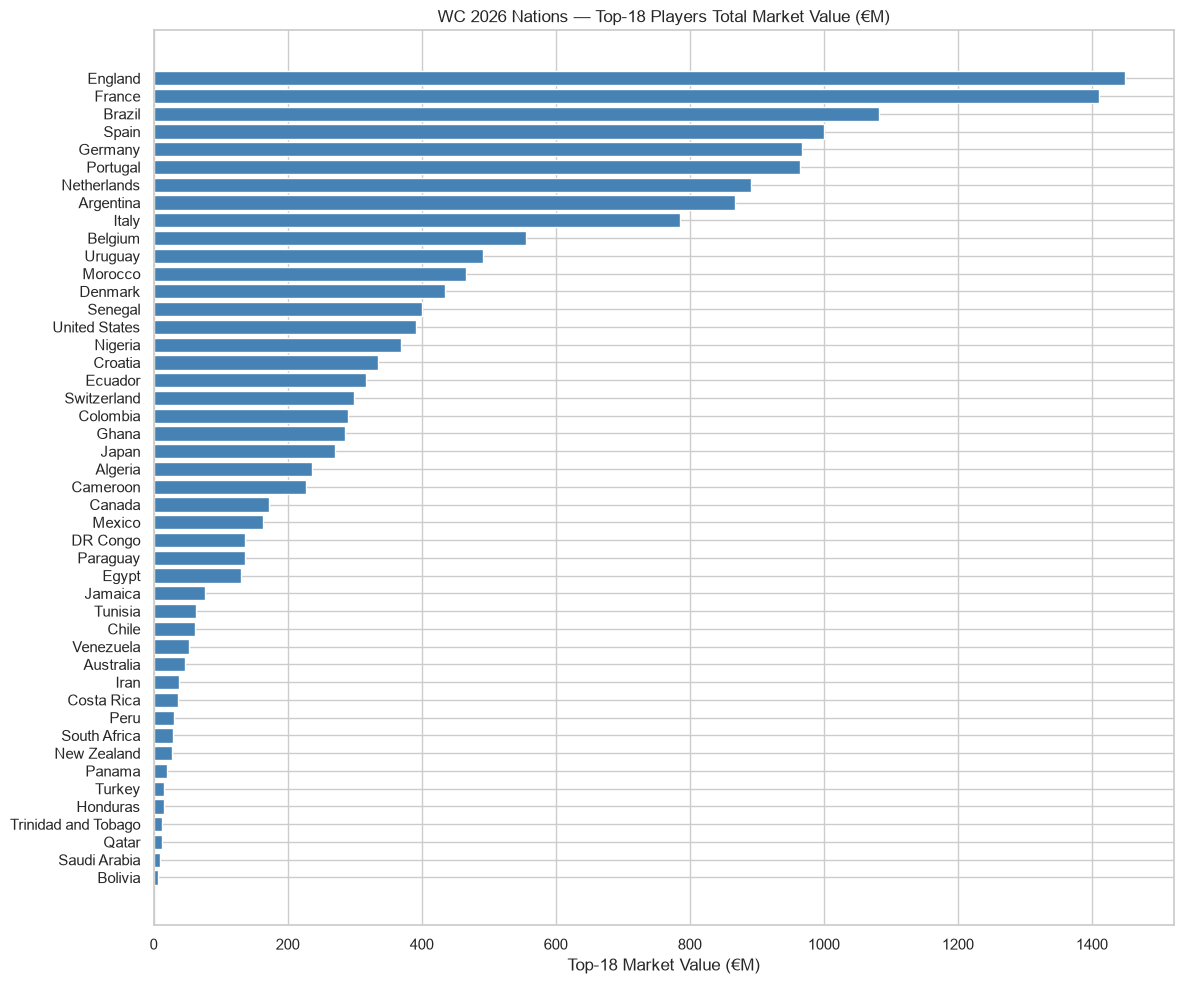

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
plot_data = wc_coverage.sort_values('top18_value_m')
ax.barh(plot_data['country_of_citizenship'], plot_data['top18_value_m'], color='steelblue')
ax.set_title('WC 2026 Nations — Top-18 Players Total Market Value (€M)')
ax.set_xlabel('Top-18 Market Value (€M)')
plt.tight_layout()
plt.show()

## 5. Valuation Freshness

Valuation history shape: (507815, 6)
Date range: 2000-01-20 00:00:00 -> 2026-02-27 00:00:00

Valuations from 2025+: 14871 records for 6005 players


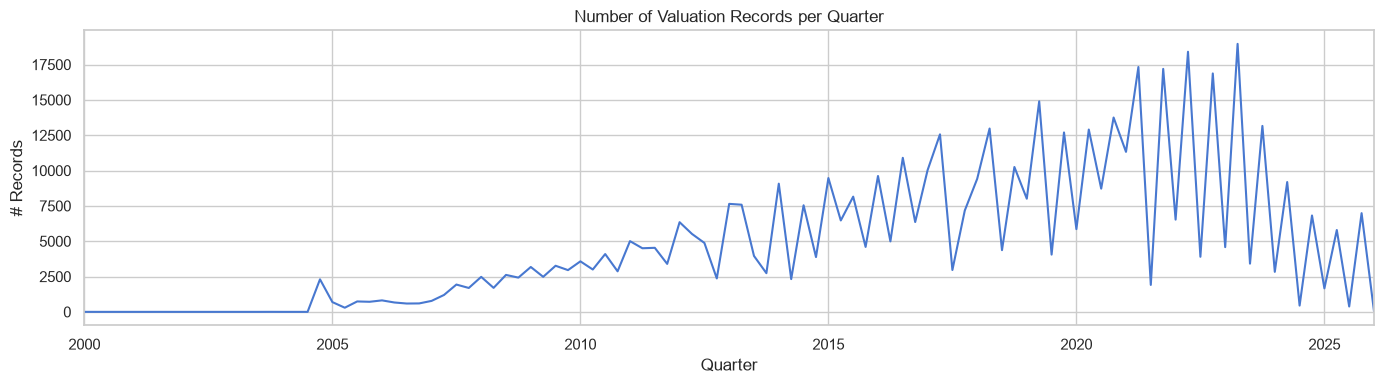

In [8]:
valuations_sorted = valuations.sort_values('date')
print('Valuation history shape:', valuations.shape)
print('Date range:', valuations['date'].min(), '->', valuations['date'].max())

# How many players have valuations in the last year (2025+)?
recent_valuations = valuations[valuations['date'] >= '2025-01-01']
print(f'\nValuations from 2025+: {len(recent_valuations)} records for {recent_valuations["player_id"].nunique()} players')

fig, ax = plt.subplots(figsize=(14, 4))
valuations.set_index('date')['market_value_in_eur'].resample('QE').count().plot(ax=ax)
ax.set_title('Number of Valuation Records per Quarter')
ax.set_xlabel('Quarter')
ax.set_ylabel('# Records')
plt.tight_layout()
plt.show()

## 6. Market Value Skew & Log-Normality

Skewness (raw): 10.87  (>1 = right-skewed, consider log transform for modeling)
Skewness (log): 0.80
Kurtosis (raw): 180.33
Kurtosis (log): 0.81


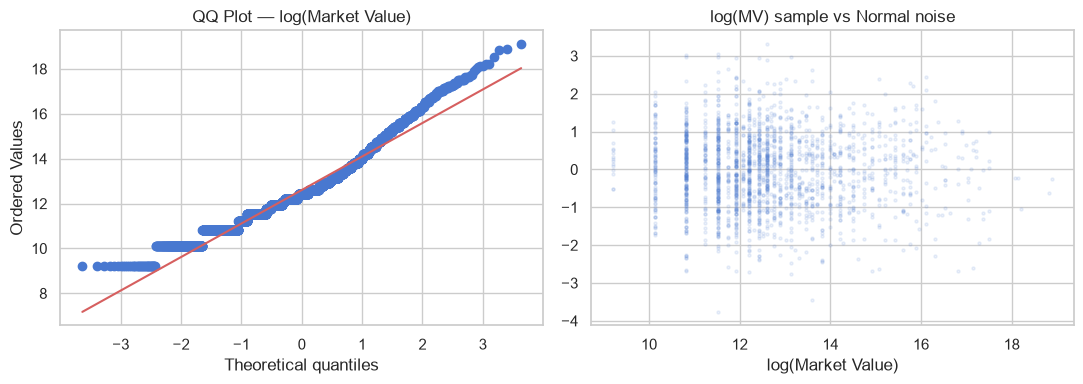

Recommendation: use log(market_value) as squad feature input to avoid scale dominance by top players


In [9]:
from scipy import stats

vals = players_with_value['market_value_in_eur'].clip(1)
log_vals = np.log(vals)

print(f'Skewness (raw): {vals.skew():.2f}  (>1 = right-skewed, consider log transform for modeling)')
print(f'Skewness (log): {log_vals.skew():.2f}')
print(f'Kurtosis (raw): {vals.kurtosis():.2f}')
print(f'Kurtosis (log): {log_vals.kurtosis():.2f}')

# QQ plot for log values
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(log_vals.sample(min(5000, len(log_vals)), random_state=42), dist='norm', plot=axes[0])
axes[0].set_title('QQ Plot — log(Market Value)')

axes[1].scatter(log_vals.sample(min(2000, len(log_vals)), random_state=42),
                np.random.normal(0, 1, min(2000, len(log_vals))), alpha=0.1, s=5)
axes[1].set_xlabel('log(Market Value)')
axes[1].set_title('log(MV) sample vs Normal noise')

plt.tight_layout()
plt.show()
print('Recommendation: use log(market_value) as squad feature input to avoid scale dominance by top players')

## 7. Red Flags Summary

In [10]:
import datetime
red_flags = []
today = datetime.date(2026, 6, 12)

missing_pct = players['market_value_in_eur'].isnull().mean() * 100
if missing_pct > 30:
    red_flags.append(f'{missing_pct:.1f}% of players have no market value — squad aggregate will drop players; check if WC squad players are covered')

latest_val_date = valuations['date'].max()
days_stale = (today - latest_val_date.date()).days
if days_stale > 90:
    red_flags.append(f'Latest valuation is {days_stale} days old ({latest_val_date.date()}) — misses June 2026 squad fitness; acceptable for pre-tournament squad estimation')

if missing_teams:
    red_flags.append(f'WC 2026 team name mismatches needing harmonization: {missing_teams[:5]}')

if red_flags:
    print('RED FLAGS:')
    for f in red_flags:
        print(' -', f)
else:
    print('No red flags.')

print()
print('MODELING NOTE: Use log(sum of top-18 market values) as squad strength feature.')
print('Need to join players to national teams via squad lists (see notebook 06).')

RED FLAGS:
 - 34.0% of players have no market value — squad aggregate will drop players; check if WC squad players are covered
 - Latest valuation is 105 days old (2026-02-27) — misses June 2026 squad fitness; acceptable for pre-tournament squad estimation
 - WC 2026 team name mismatches needing harmonization: ['Ivory Coast', 'South Korea']

MODELING NOTE: Use log(sum of top-18 market values) as squad strength feature.
Need to join players to national teams via squad lists (see notebook 06).
